In [ ]:
# To run only once or else restart the kernel
# or change manually the current directory so that it is Networks_project/
import os
os.chdir("../")

In [2]:
import numpy as np
import pandas as pd
import networkx as nx
import statsmodels.api as sm

In [ ]:
from src.geography_utils import construction_reseau_physique, haversine

## Importation des datasets

In [4]:
path_data_check_in='data/dataset_TSMC2014_TKY.txt'
path_data_users='data/dataset_UbiComp2016_UserProfile_TKY.txt'

df_checkins = pd.read_csv(
        path_data_check_in,
        sep='\t',
        encoding='latin-1',
        header=None,
        names=[
            'user_id','location_id','location_type_ID',
            'location_type_name','latitude','longitude',
            'timezone','timestamp', 'Venue_Category_Name'
        ]
    )

df_users = pd.read_csv(
        path_data_users,
        sep='\t',
        encoding='latin-1',
        header=None,
        names=[
            'user_id','gender','nb_twitter_friends',
            'nb_twitter_followers'
        ]
    )

In [5]:
# On regroupe les établissements par catégorie (les plus fréquentes)

col = df_checkins['location_type_name'].str.strip()

df_checkins['category_grouped'] = np.select(
    [

        #Restaurants (tous les noms contenant "Restaurant")
        col.str.contains("Restaurant|Ramen", case=False, na=False),

        # Retail (Shop / Store)
        col.str.contains("Shop|Store|Mall", case=False, na=False),

        # Food & Drink spécifiques
        col.isin(["Café", "Coffee Shop", "Bar"]),

        #  Transport
        col.isin(["Train Station", "Bus Station", "Subway"]),

        #  Services
        col.isin(["Office", "Medical Center"]),

        #  Outdoor / infrastructure
        col.isin(["Park", "Road", "Bridge"])

    ],
    [
        "FOOD_RESTAURANT",
        "RETAIL",
        "FOOD_DRINK",
        "TRANSPORT",
        "SERVICES",
        "OUTDOOR"
    ],
    default="OTHER"
)

## Preprocessing

### Côté utilisateur

On commence par définir la maison des utilisateurs par le centroïde des lieux qu'ils ont visités.

In [6]:
def get_centroid(df):
    # Conversion en radians
    lat = np.radians(df['latitude'])
    lon = np.radians(df['longitude'])
    
    # Passage en cartésien
    x = np.cos(lat) * np.cos(lon)
    y = np.cos(lat) * np.sin(lon)
    z = np.sin(lat)
    
    # Moyenne des coordonnées
    avg_x = x.mean()
    avg_y = y.mean()
    avg_z = z.mean()
    
    # Reconversion en Sphérique
    central_lon = np.arctan2(avg_y, avg_x)
    central_hyp = np.sqrt(avg_x**2 + avg_y**2)
    central_lat = np.arctan2(avg_z, central_hyp)
    
    return pd.Series({
        'lat_home': np.degrees(central_lat),
        'lon_home': np.degrees(central_lon)
    })

# Application par utilisateur
user_home = df_checkins.groupby('user_id').apply(get_centroid).reset_index()

On enrichit les checkins initiaux par les informations utiles sur les utilisateurs.

In [7]:
user_profiles = pd.merge(user_home, df_users[['user_id', 'nb_twitter_followers']], on='user_id')
df_final = pd.merge(df_checkins, user_profiles, on='user_id')

On calcule ensuite les distances parcourues pour chaque check-in.

In [9]:
df_final['distance_km'] = haversine(
    df_final['lat_home'], df_final['lon_home'],
    df_final['latitude'], df_final['longitude']
)

df_final = df_final[[
    'user_id', 'location_id', 'latitude', 'longitude', 
    'lat_home', 'lon_home', 'nb_twitter_followers', 'distance_km',
    'category_grouped'
]]

### Côté lieu

On veut relier les lieux entre eux par leur nombre de visiteurs communs.

In [10]:
# On s'assure de ne prendre que les lieux UNIQUES par utilisateur pour les arêtes
df_user_checkins = df_final.groupby('user_id').agg({
    'location_id': lambda x: list(set(x))
}).reset_index()

df_user_checkins = df_user_checkins.merge(df_users[["user_id", "nb_twitter_followers"]], on="user_id", how="left").fillna(0)

In [11]:
df_lieux = df_final.groupby("location_id").agg({
    "user_id": "count",
    "latitude": "first",
    "longitude": "first",
    "nb_twitter_followers": "sum",
    "category_grouped": "first"
}).rename(columns={
    "user_id": "nb_checkins",       # Remove duplicates
    "nb_twitter_followers": "popularity"
}).reset_index()

In [13]:
G = construction_reseau_physique(df_lieux=df_lieux, df_user_checkins=df_user_checkins)

In [14]:
G.nodes[list(G.nodes)[0]]

{'pop': 5663,
 'lat': 35.69071166859883,
 'lon': 139.69111919403076,
 'category': 'OTHER'}

In [15]:
len(G.nodes)

21774

## Loi de Newton

On cherche à calculer des poids entre deux lieux à partir d'un modèle de Newton :

$$ G_{uv} = P_u P_v f(\Delta_{uv}) $$

On suppose que $\exist \alpha > 0 | \forall x > 0, f(x) = x^\alpha $.

In [16]:
details_lieux = df_lieux.set_index("location_id")

In [ ]:
edge_data = []
details_lieux = df_lieux.set_index("location_id")

for u, v, d in G.edges(data=True):
    try:
        node_u = details_lieux.loc[u]
        node_v = details_lieux.loc[v]
        
        # Correction des noms de colonnes : latitude/longitude au lieu de lat/lon
        dist = haversine(node_u['latitude'], node_u['longitude'], 
                         node_v['latitude'], node_v['longitude'])
        
        mass_prod = node_u['popularity'] * node_v['popularity']
        
        # Filtre pour éviter log(0) ou log(négatif)
        if dist > 0.001 and mass_prod > 0:
            edge_data.append({
                'weight': d['weight'],
                'mass': mass_prod,
                'dist': dist,
                'log_weight': np.log(d['weight']),
                'log_mass': np.log(mass_prod),
                'log_dist': np.log(dist),
            })
    except Exception as e:
        print(u, v)
        continue 

df_stats = pd.DataFrame(edge_data)

Tentons avec une régression log-log :

In [23]:
X = df_stats[['log_mass', 'log_dist']]
X = sm.add_constant(X)
y = df_stats['log_weight']
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_weight   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                 1.467e+05
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:07:24   Log-Likelihood:             2.3289e+05
No. Observations:             2259623   AIC:                        -4.658e+05
Df Residuals:                 2259620   BIC:                        -4.657e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3497      0.001   -441.874      0.0

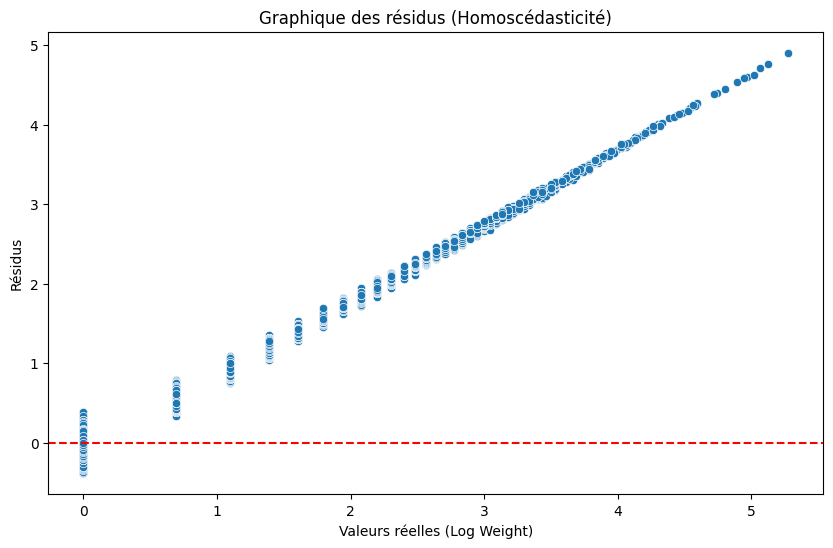

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

residus = model.resid

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y, y=residus)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Graphique des résidus (Homoscédasticité)")
plt.xlabel("Valeurs réelles (Log Weight)")
plt.ylabel("Résidus")
plt.show()

La prédiction est toujours 0.

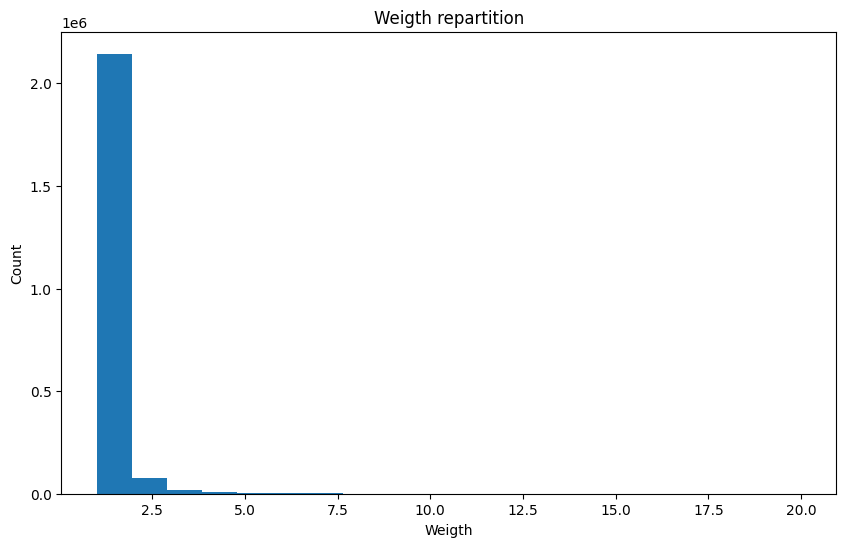

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df_stats[df_stats["weight"] <= 20]["weight"], bins=20)
plt.title("Weigth repartition")
plt.xlabel("Weigth")
plt.ylabel("Count")
plt.show()

On constate que c'est parce que weight est la grande majorité du temps égal à 1.

In [67]:
df_stats_filtered = df_stats[df_stats['weight'] >= 2]

X = df_stats_filtered[['log_mass', 'log_dist']]
X = sm.add_constant(X)
y = df_stats_filtered['log_weight']
model_filtered = sm.OLS(y, X).fit()
print(model_filtered.summary())

                            OLS Regression Results                            
Dep. Variable:             log_weight   R-squared:                       0.271
Model:                            OLS   Adj. R-squared:                  0.271
Method:                 Least Squares   F-statistic:                 2.142e+04
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:26:56   Log-Likelihood:                -54368.
No. Observations:              115275   AIC:                         1.087e+05
Df Residuals:                  115272   BIC:                         1.088e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.3981      0.011   -122.018      0.0

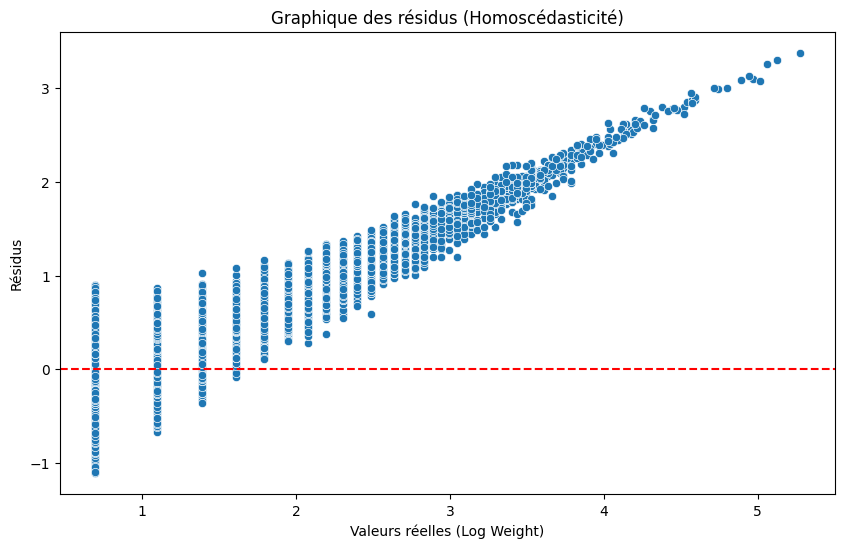

In [68]:
residus = model_filtered.resid

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y, y=residus)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Graphique des résidus (Homoscédasticité)")
plt.xlabel("Valeurs réelles (Log Weight)")
plt.ylabel("Résidus")
plt.show()

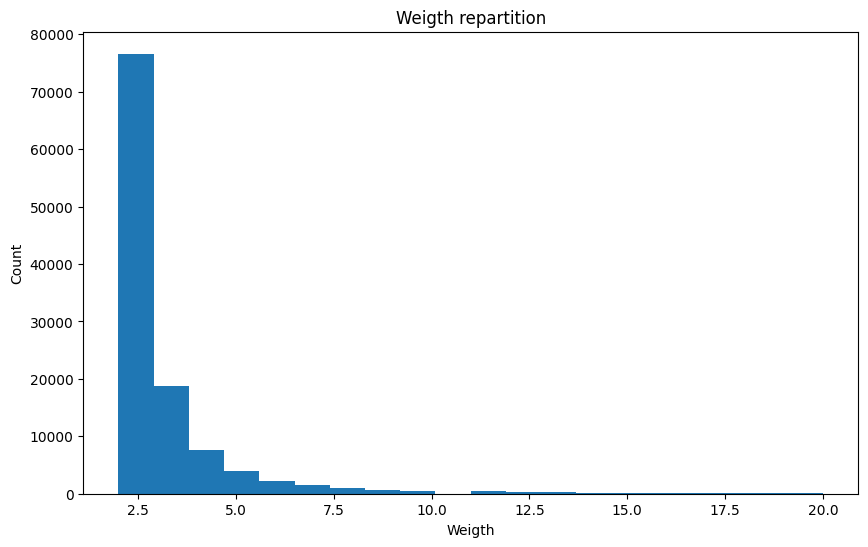

In [66]:
plt.figure(figsize=(10, 6))
plt.hist(df_stats_filtered[df_stats_filtered["weight"] <= 20]["weight"], bins=20)
plt.title("Weigth repartition")
plt.xlabel("Weigth")
plt.ylabel("Count")
plt.show()

**Conclusion** : on a du mal à appliquer un modèle de Newton sur les poids des liens entre lieux, possiblement à cause de la répartition non uniforme des poids réels.

## Autre approche de Newton

Cette fois-ci on va regarder l'influence des lieux par rapport aux utilisateurs, c'est-à-dire de mesurer comment un lieu attire des gens pr

In [69]:
venue_stats = df_final.groupby('location_id').agg({
    'nb_twitter_followers': 'sum', # Somme de l'influence reçue
    'distance_km': 'mean',         # Distance moyenne parcourue par les visiteurs
    'user_id': 'count'             # Nombre total de check-ins (pour comparer)
}).rename(columns={'nb_twitter_followers': 'total_influence_score'})

In [ ]:
ALPHA = 1.5 
G_const = 1.0

df_gravity = df_final.copy()

# 1. Éviter la division par zéro
df_gravity['distance_km'] = df_gravity['distance_km'].clip(lower=0.1)

# 2. Calculer la force d'attraction individuelle pour chaque check-in
df_gravity['attraction_force'] = G_const * (df_gravity['nb_twitter_followers'] / np.power(df_gravity['distance_km'], ALPHA))

# 3. Aggréger par lieu (Location)
venue_results = df_gravity.groupby('location_id').agg({
    'attraction_force': 'sum',          # Score de Newton (Popularité prédite)
    'nb_twitter_followers': 'sum',      # Masse totale reçue
    'user_id': 'count',                 # Nombre de check-ins réels
    'distance_km': 'mean',              # Distance moyenne parcourue
    'latitude': 'first',                # Pour cartographie
    'longitude': 'first'
}).rename(columns={
    'attraction_force': 'gravity_score',
    'user_id': 'visit_count',
    'nb_twitter_followers': 'total_followers_mass'
})

# 4. Normalisation
venue_results['gravity_score_norm'] = (venue_results['gravity_score'] / venue_results['gravity_score'].max()) * 100

# 5. Trier par les lieux les plus attractifs
top_venues = venue_results.sort_values(by='gravity_score', ascending=False)

print("Top 10 des lieux par score de gravité à Tokyo :")
top_venues[['gravity_score_norm', 'visit_count', 'total_followers_mass']].head(10)

Top 10 des lieux par score de gravité à Tokyo :


,gravity_score_norm,visit_count,total_followers_mass
location_id,,,
4b19f917f964a520abe623e3,100.000000,2720,2962607
4b77bb92f964a52095a82ee3,63.628330,73,49713
4b5ccea3f964a520044529e3,58.145497,533,1122654
4b0587a6f964a5203d9e22e3,43.053739,2471,2460800
4b0587a6f964a5203e9e22e3,39.153917,945,1206907
4b1211bcf964a520cb8823e3,35.948039,195,224111
4c2d76ee7d85a593d0c252f3,34.189489,16,30461
4b4327e6f964a5209fdc25e3,31.951869,222,228207
4b55670ff964a52071e327e3,31.877774,661,846538


In [73]:
correlation = venue_results['gravity_score'].corr(venue_results['visit_count'])
print(f"\nCorrélation entre le modèle de Newton et les visites réelles : {correlation:.4f}")


Corrélation entre le modèle de Newton et les visites réelles : 0.6999


In [74]:
correlation = venue_results['total_followers_mass'].corr(venue_results['visit_count'])
print(f"\nCorrélation entre la masse et les visites réelles : {correlation:.4f}")


Corrélation entre la masse et les visites réelles : 0.7465


La corrélation est plus forte entre la masse de followers et le nombre de checkins plutôt qu'entre le score de gravité et la masse de followers : le modèle est à nouveau invalide.

On regarde si on peut trouver un paramètre $\alpha$ idéal grâce à une OLS :

In [75]:
import statsmodels.api as sm
import numpy as np

# 1. Préparation des données pour le test
# On travaille sur les lieux (venues)
test_df = venue_results.copy()

# On évite les log(0)
test_df = test_df[test_df['total_followers_mass'] > 0]
test_df = test_df[test_df['distance_km'] > 0]

# 2. Transformation Logarithmique
# Variable à expliquer (Y) : Nombre de visites réelles
# Variables explicatives (X) : Masse des followers et Distance
test_df['log_visits'] = np.log(test_df['visit_count'])
test_df['log_mass'] = np.log(test_df['total_followers_mass'])
test_df['log_dist'] = np.log(test_df['distance_km'])

# 3. Définition du modèle OLS (Ordinary Least Squares)
# Y = Intercept + beta1 * log_mass + beta2 * log_dist
X = test_df[['log_mass', 'log_dist']]
X = sm.add_constant(X) # Ajoute l'intercept (G dans Newton)
Y = test_df['log_visits']

model = sm.OLS(Y, X).fit()

# 4. Affichage des résultats
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_visits   R-squared:                       0.474
Model:                            OLS   Adj. R-squared:                  0.474
Method:                 Least Squares   F-statistic:                     9823.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:39:47   Log-Likelihood:                -24145.
No. Observations:               21774   AIC:                         4.830e+04
Df Residuals:                   21771   BIC:                         4.832e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2228      0.024    -93.576      0.0

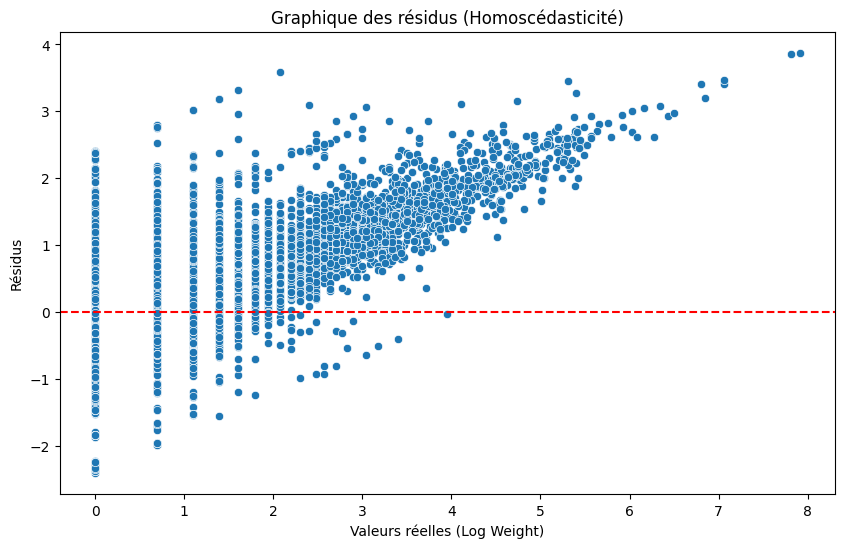

In [76]:
residus = model.resid

plt.figure(figsize=(10, 6))
sns.scatterplot(x=Y, y=residus)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Graphique des résidus (Homoscédasticité)")
plt.xlabel("Valeurs réelles (Log Weight)")
plt.ylabel("Résidus")
plt.show()

Les résidus sont autocorrellés, on ne peut pas dire que notre modèle est correct.